# Session 6- Classification

## Classification- NN (Nearest neighbour) - Manhattan and Euclidean (distance metrics) - Cosine and Jaccard (Similiraty metrics) - KNN (as model) - Local outlier factor (as a tool not a model) - Hyperparameters for classification (n_neighbour , weight, algorythm (kd-tree, P, metrics(minkowish))), Recommender system - Confusion matrix - Precision- F1 - Accuracy - Recall    

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.neighbors import KNeighborsClassifier

## Classification - KNN model - Local outlier factor 

In [21]:
# make data for classification
X,y = make_blobs(
    n_samples = 50,
    n_features = 2,
    centers = 3,
    cluster_std = 2.5,
    random_state=42
)

print(X.shape)
np.unique(y,return_counts= True)


(50, 2)


(array([0, 1, 2]), array([17, 17, 16], dtype=int64))

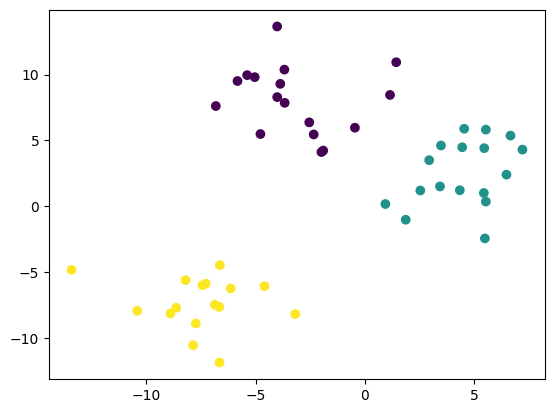

In [24]:
# Visualize
plt.scatter(X[:,0],X[:,1],c = y)

(1, 2)


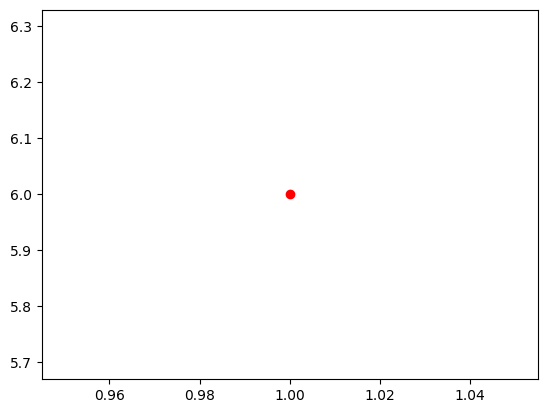

In [42]:
#add new point:
new_point = np.array([[1,6]])
print(new_point.shape)

plt.scatter(new_point[:,0] , new_point[:,1], c="red")


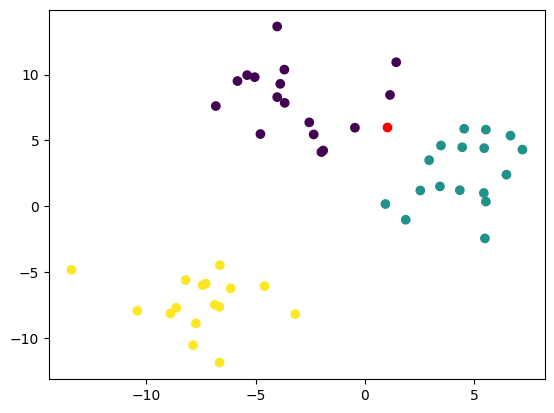

In [43]:
# Visualize

plt.scatter(X[:,0],X[:,1],c = y)
plt.scatter(new_point[:,0] , new_point[:,1], c="red")


In [63]:
# KNN model to predict new point
cl_model = KNeighborsClassifier(
    n_neighbors=5,
    n_jobs = -1
)

# hyperparameters: n_neighbor : compare your score with how many numbers? --
# n_jobs : the number of your cpu core it use (-1 all use)

# Using predict to see each color belongs to wich classes [0,1,2]
new_point = np.array([[-10,-7]])

cl_model.fit(X,y)

cl_model.predict(new_point) #array([2]) so yellow is 2 

classes = {2:'yellow' , }

new_point = np.array([[-3,10]])
cl_model.predict(new_point)   #a rray([0]) is purple


classes = {0: "purple", 1:"green", 2:"yellow"}


new_point = np.array([[3,8]])
classes[cl_model.predict(new_point)[0]] #0 because we cannot print array we can print value

'green'

In [88]:
cl_model.fit(X,y)
# Norm 1 (L1)  = Manhattan  = Σ|xᵢ|
# Norm 2 (L2)  = Euclidean  = √Σ(xᵢ²)

# KNeighborsClassifier(weights='uniform')   # All neighbors equal
# KNeighborsClassifier(weights='distance')  # Closer = more important

# KNeighborsClassifier(algorithm='auto')       # Default — picks best
# KNeighborsClassifier(algorithm='ball_tree')  # Fast for high dimensions
# KNeighborsClassifier(algorithm='kd_tree')    # Fast for low dimensions
# KNeighborsClassifier(algorithm='brute')      # Slow but exact it measures all point 

# KNeighborsClassifier(metric='euclidean')   # Default p=2
# KNeighborsClassifier(metric='manhattan')   # Same as p=1
# KNeighborsClassifier(metric='minkowski')   # Use with p
# KNeighborsClassifier(metric='cosine')      # Text data

# KNeighborsClassifier(n_jobs=1)    # Use 1 CPU core
# KNeighborsClassifier(n_jobs=-1)   # Use ALL CPU cores
# KNeighborsClassifier(n_jobs=4)    # Use 4 cores

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,-1


In [83]:
#Local outlier factor
# this is a tool for finding the outlier not a model for predict 
heights = np.array([159,165,177,180,130,188,189,194,145,220]).reshape(-1,1)

from sklearn.neighbors import LocalOutlierFactor
lof = LocalOutlierFactor(n_neighbors=5)
lof.fit(heights)

# lof.predict(heiths) #This 'LocalOutlierFactor' has no attribute 'predict'
lof.fit_predict(heights)
#-1 is outlier 1 is normal

LocalOutlierFactor(n_neighbors=5)


array([ 1,  1,  1,  1, -1,  1,  1,  1,  1, -1])

In [87]:
lof.fit(heights)

,n_neighbors,5
,algorithm,'auto'
,leaf_size,30
,metric,'minkowski'
,p,2
,metric_params,None
,contamination,'auto'
,novelty,False
,n_jobs,None


## Confusion matrix( precision, F1, recall(TPR), Accuray) 

In [104]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report,confusion_matrix
import numpy as np

In [111]:
# Cancer detiction = so P = hace cancer N = noraml- cancer = 1, norma; =0
X = np.array([1,2,3,4,5,6,7,8,9,10])

y_true= np.array([0,0,0,0,0,1,1,1,1,1])

y_pred = ([0,0,0,0,1,1,1,1,1,1])

print(f'Accuracy: {accuracy_score(y_true,y_pred)}')
print(f'precision: {precision_score(y_true,y_pred)}')
print(f'Recall: {recall_score(y_true,y_pred)}')
print(f'F1: {f1_score(y_true,y_pred)}')

#precision: 0.8333333333333334
#Recall: 1.0

#Precision 83%: "When the model says YES, it's right 83% of the time."
 #              → 17% of positive predictions are WRONG (false alarms)

#Recall 100%:   "The model found EVERY positive case."
 #              → Zero misses — perfect at catching all positives!

Accuracy: 0.9
precision: 0.8333333333333334
Recall: 1.0
F1: 0.9090909090909091


In [112]:
confusion_matrix(y_true,y_pred)

  #         Negetive  Posutive      
   #  Negetive   [[4,  1],
   # Positive   [0,  5]]

array([[4, 1],
       [0, 5]], dtype=int64)

In [113]:
# all metrics in one line
print(classification_report(y_true, y_pred))

#NORMAL (Class 0, 5 patients):
#  Precision 100%: Everyone said "normal" WAS normal (zero false alarms)
 # Recall 80%:    1 of 5 normal patients was WRONGLY called cancer
  #                → 1 person unnecessarily scared

#CANCER (Class 1, 5 patients):
 # Precision 83%: 1 of 6 "cancer" diagnoses was actually normal (false alarm)
  # Recall 100%:   ALL 5 cancer patients were FOUND (zero missed!)
    #              → No cancer patient sent home

              precision    recall  f1-score   support

           0       1.00      0.80      0.89         5
           1       0.83      1.00      0.91         5

    accuracy                           0.90        10
   macro avg       0.92      0.90      0.90        10
weighted avg       0.92      0.90      0.90        10



## Problem - Use confusion matrix on make_blobs data

(20, 2)


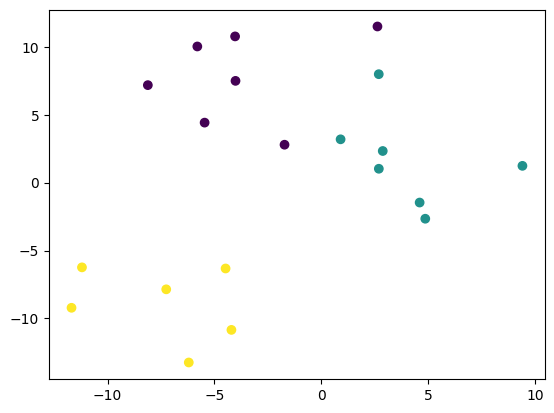

In [130]:
# make data for classification
X,y = make_blobs(
    n_samples =20,
    n_features = 2,
    centers = 3,
    cluster_std = 3.25,
    random_state=42
)

print(X.shape)
np.unique(y,return_counts= True)
plt.scatter(X[:,0],X[:,1],c = y)


In [137]:
# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,stratify=y, test_size=0.3, random_state=42)

# Train model
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Predict
y_pred = knn.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)
print(classification_report(y_test,y_pred))

[[1 1 0]
 [0 2 0]
 [0 0 2]]
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.67      1.00      0.80         2
           2       1.00      1.00      1.00         2

    accuracy                           0.83         6
   macro avg       0.89      0.83      0.82         6
weighted avg       0.89      0.83      0.82         6

